In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import datetime as dt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from matplotlib.patches import Patch
from sklearn.cluster import DBSCAN

In [ ]:
path = kagglehub.dataset_download("hellbuoy/online-retail-customer-clustering")
print("Path to dataset files:", path)

In [4]:
import os

print(os.listdir(path))

['OnlineRetail.csv']


In [5]:
retail = pd.read_csv(os.path.join(path, "OnlineRetail.csv"), encoding="ISO-8859-1")
print(f"Loaded {retail.shape[0]} rows, {retail.shape[1]} columns")
retail.head()

Loaded 541909 rows, 8 columns


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [6]:
retail.shape

(541909, 8)

In [7]:
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
retail.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
retail.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
len(retail)

541909

In [11]:
df_null = round(100 * (retail.isnull().sum()) / len(retail), 2)
df_null

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     24.93
Country         0.00
dtype: float64

In [12]:
retail.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
retail["Description"].isnull().sum()

1454

In [14]:
retail[retail["Description"].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,01-12-2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,01-12-2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,01-12-2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,01-12-2010 14:34,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,07-12-2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,07-12-2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,07-12-2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,08-12-2011 10:33,0.0,NaN,United Kingdom


In [15]:
retail = retail.dropna()
retail.shape

(406829, 8)

In [16]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [17]:
negative_qty = retail[retail["Quantity"] < 0]
print(f"Total returns: {len(negative_qty)}")
negative_qty

Total returns: 8905


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,01-12-2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01-12-2010 09:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,01-12-2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,01-12-2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,09-12-2011 09:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,09-12-2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,09-12-2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,09-12-2011 11:58,1.25,17315.0,United Kingdom


In [18]:
retail["CustomerID"] = retail["CustomerID"].astype(str)

In [19]:
retail["CustomerID"].dtype

dtype('O')

In [20]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


- **Total revenue (Monetary):** Quantity × Price
- **RFM model:** 

  - **RFM_M**: **Monetary:** Total amount of transactions (revenue contributed)


In [21]:
retail["Amount"] = retail["Quantity"] * retail["UnitPrice"]
rfm_m = retail.groupby("CustomerID")["Amount"].sum()
rfm_m = rfm_m.reset_index()
rfm_m.head()

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


 - **Frequency:** How often a customer makes purchases
 - identify unique customers
 - count individual transactions (Invoice)

In [22]:
rfm_f = retail.groupby("CustomerID")["InvoiceNo"].count()
rfm_f = rfm_f.reset_index()
rfm_f.columns = ["CustomerID", "Frequency"]
rfm_f.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


- Merging both dataframe

In [23]:
rfm = pd.merge(rfm_m, rfm_f, on="CustomerID", how="inner")
rfm.head()

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


In [24]:
retail.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


- **Recency:** How recently a customer made a purchase  
  (Date today − Date last purchase)


In [25]:
# Convert to datetime

retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"], format="%d-%m-%Y %H:%M")

In [26]:
retail.head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.3


In [27]:
# to know the last transaction date
max_date = max(retail["InvoiceDate"])
max_date

Timestamp('2011-12-09 12:50:00')

In [28]:
# Diff between last and transaction date
retail["Diff"] = max_date - retail["InvoiceDate"]
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


In [29]:
# last transaction date to get the recency of customers
rfm_p = retail.groupby("CustomerID")["Diff"].min()
rfm_p = rfm_p.reset_index()
rfm_p.head()

,CustomerID,Diff
0,12346.0,325 days 02:33:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


In [30]:
rfm_p["Diff"] = rfm_p["Diff"].dt.days
rfm_p.head()

,CustomerID,Diff
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [31]:
# Merge dataset

rfm = pd.merge(rfm, rfm_p, on="CustomerID", how="inner")
rfm.columns = ["CustomerID", "Amount", "Frequency", "Recency"]
rfm.head()

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


Text(0.5, 0, 'Attributes')

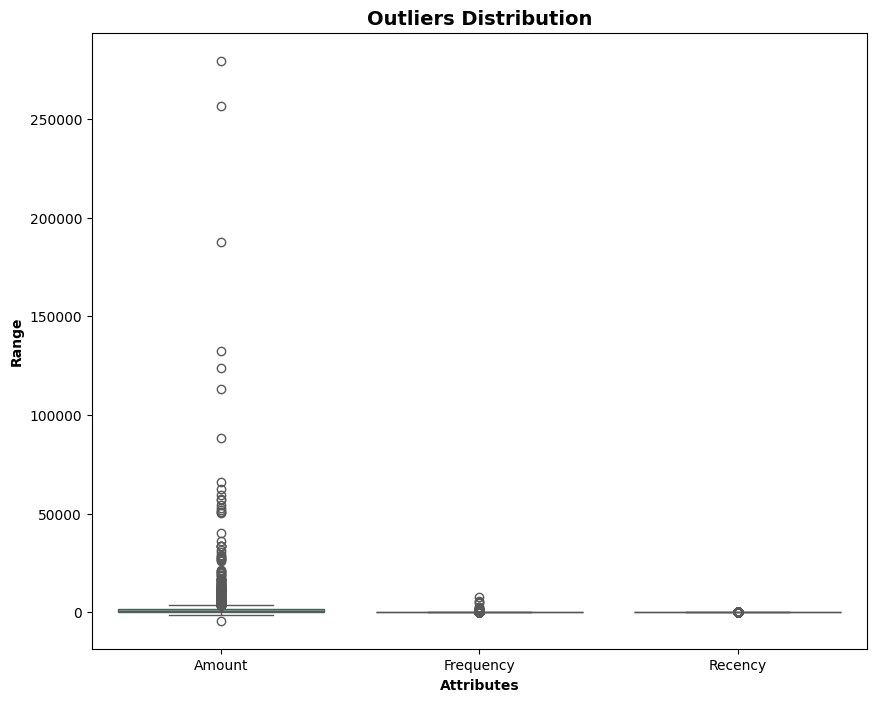

In [32]:
attributes = ["Amount", "Frequency", "Recency"]
plt.figure(figsize=(10, 8))
sns.boxplot(data=rfm[attributes], palette="Set2")
plt.title("Outliers Distribution", fontsize=14, fontweight="bold")
plt.ylabel("Range", fontweight="bold")
plt.xlabel("Attributes", fontweight="bold")

In [33]:
rfm

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309
...,...,...,...,...
4367,18280.0,180.60,10,277
4368,18281.0,80.82,7,180
4369,18282.0,176.60,13,7
4370,18283.0,2094.88,756,3


In [34]:
rfm.Recency.quantile(0.05)

2.0

In [35]:
rfm.Recency.quantile(0.95)

312.0

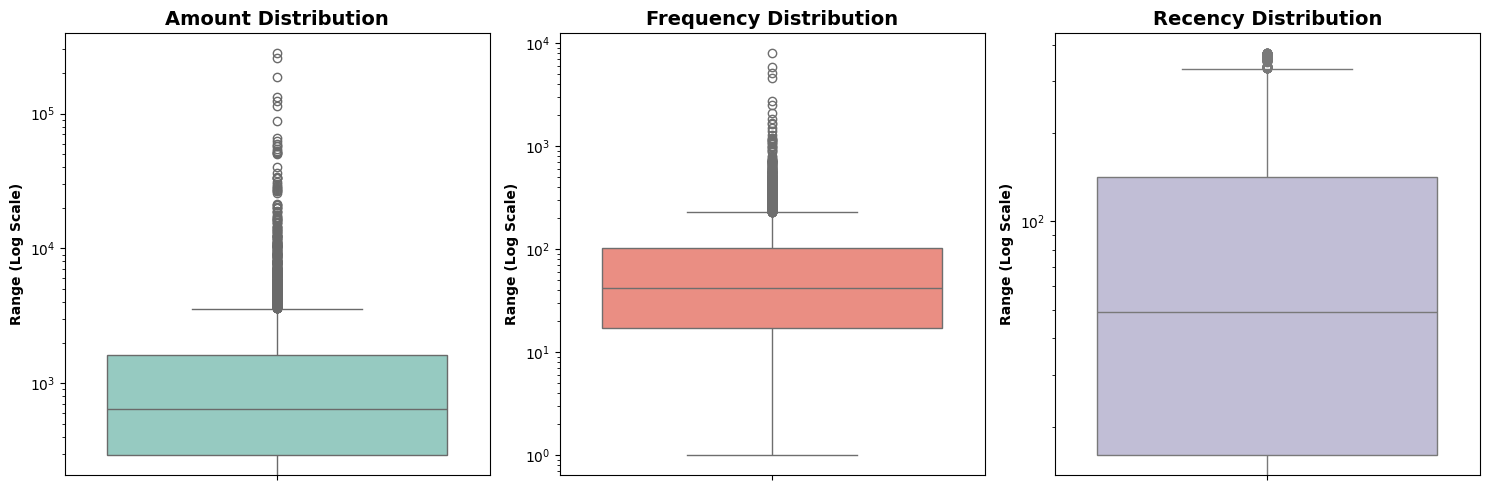

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ["#8dd3c7", "#fb8072", "#bebada"]

for i, attr in enumerate(attributes):
    sns.boxplot(y=rfm[attr], ax=axes[i], color=colors[i])
    axes[i].set_title(f"{attr} Distribution", fontsize=14, fontweight="bold")
    axes[i].set_ylabel("Range (Log Scale)", fontweight="bold")
    axes[i].set_yscale("log")

plt.tight_layout()
plt.show()

In [37]:
# Check percentile values to see where extremes are
print("Percentile Analysis:")

percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
for attr in attributes:
    print(f"\n{attr}:")
    for p in percentiles:
        value = rfm[attr].quantile(p)
        print(f"{int(p*100)}th percentile: {value:,.2f}")

Percentile Analysis:

Amount:
1th percentile: 0.00
5th percentile: 101.14
10th percentile: 146.02
25th percentile: 293.36
50th percentile: 648.08
75th percentile: 1,611.72
90th percentile: 3,505.60
95th percentile: 5,625.00
99th percentile: 17,226.29

Frequency:
1th percentile: 1.00
5th percentile: 4.00
10th percentile: 7.00
25th percentile: 17.00
50th percentile: 42.00
75th percentile: 102.00
90th percentile: 212.00
95th percentile: 317.90
99th percentile: 671.87

Recency:
1th percentile: 0.00
5th percentile: 2.00
10th percentile: 4.00
25th percentile: 16.00
50th percentile: 49.00
75th percentile: 142.00
90th percentile: 263.00
95th percentile: 312.00
99th percentile: 368.00


In [38]:
# Removing outliers for Amount
Q1 = rfm.Amount.quantile(0.05)
Q3 = rfm.Amount.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Amount >= Q1 - 1.5 * IQR) & (rfm.Amount <= Q3 + 1.5 * IQR)]

# Removing outliers for Recency
Q1 = rfm.Recency.quantile(0.05)
Q3 = rfm.Recency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Recency >= Q1 - 1.5 * IQR) & (rfm.Recency <= Q3 + 1.5 * IQR)]

# Removing outliers for Frequency
Q1 = rfm.Frequency.quantile(0.05)
Q3 = rfm.Frequency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Frequency >= Q1 - 1.5 * IQR) & (rfm.Frequency <= Q3 + 1.5 * IQR)]

In [39]:
rfm

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309
...,...,...,...,...
4366,18278.0,173.90,9,73
4367,18280.0,180.60,10,277
4368,18281.0,80.82,7,180
4369,18282.0,176.60,13,7


- **Rescaling the attributes:** Using standardization scaling.

In [40]:
rfm_df = rfm[["Amount", "Frequency", "Recency"]]


scaler = StandardScaler()
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled.shape

(4293, 3)

In [41]:
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.columns = ["Amount", "Frequency", "Recency"]
rfm_df_scaled.head()

,Amount,Frequency,Recency
0,-0.723738,-0.752888,2.301611
1,1.731617,1.042467,-0.906466
2,0.300128,-0.463636,-0.183658
3,0.277517,-0.044720,-0.738141
4,-0.533235,-0.603275,2.143188


### Building the Model

**K-Means Clustering**

- Initialize **k** points (centroids) randomly.
- Assign each data point to the nearest centroid.
- Update each centroid by computing the mean of the assigned points.
- Repeat the assignment and update steps for a fixed number of iterations.
- Final centroids define the resulting clusters.

In [42]:
kmeans = KMeans(n_clusters=4, max_iter=50)
kmeans.fit(rfm_df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",50
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [43]:
kmeans.labels_

array([1, 3, 0, ..., 1, 0, 0])

### Finding the Optimal Number of Clusters

- Using the **Elbow Curve** to determine the appropriate number of clusters.
- This is an essential step in unsupervised learning to identify the optimal number of clusters into which the data should be clustered.
- SSD - Sum of Squared Distance (SSD)

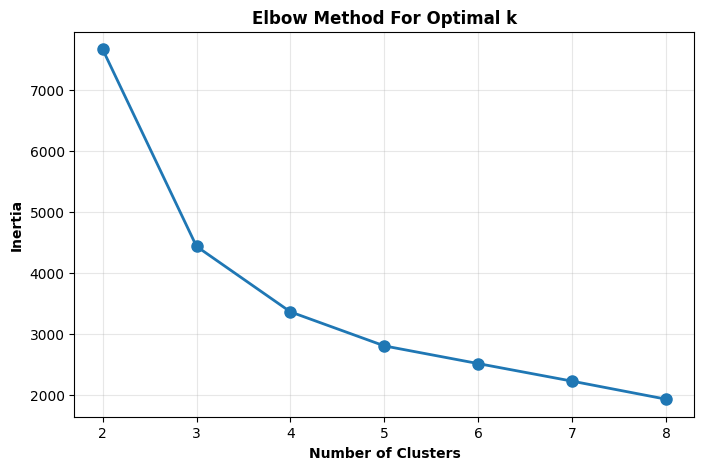

In [44]:
ssd = []
clusters = range(2, 9)

for k in clusters:
    kmeans = KMeans(n_clusters=k, max_iter=50, random_state=42)
    kmeans.fit(rfm_df_scaled)
    ssd.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(clusters, ssd, "o-", linewidth=2, markersize=8)
plt.xlabel("Number of Clusters", fontweight="bold")
plt.ylabel("Inertia", fontweight="bold")
plt.title("Elbow Method For Optimal k", fontweight="bold")
plt.xticks(clusters)
plt.grid(True, alpha=0.3)
plt.show()

k=2: 0.539
k=3: 0.508
k=4: 0.485
k=5: 0.462
k=6: 0.437
k=7: 0.408
k=8: 0.323


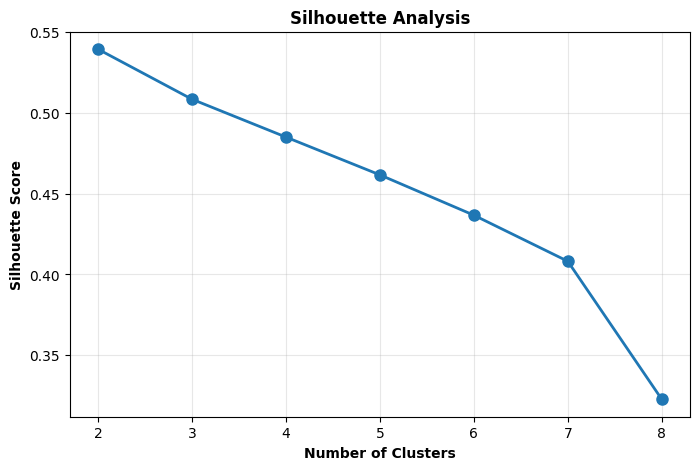

In [45]:
clusters = range(2, 9)
silhouette_scores = []

for k in clusters:
    kmeans = KMeans(n_clusters=k, max_iter=50, random_state=42)
    kmeans.fit(rfm_df_scaled)

    score = silhouette_score(rfm_df_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"k={k}: {score:.3f}")

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(clusters, silhouette_scores, "o-", linewidth=2, markersize=8)
plt.xlabel("Number of Clusters", fontweight="bold")
plt.ylabel("Silhouette Score", fontweight="bold")
plt.title("Silhouette Analysis", fontweight="bold")
plt.xticks(clusters)
plt.grid(True, alpha=0.3)
plt.show()

### Final Model

- Final model selected based on the **Elbow Method** and **Silhouette Score**.
- **n_iter:** Number of iterations the algorithm ran for the best run that converged to the final solution.
- **Inertia (WCSS):** Measures how compact (tight) the clusters are.

In [46]:
# Fit the best model
kmeans = KMeans(n_clusters=3, max_iter=300, random_state=42)
kmeans.fit(rfm_df_scaled)

rfm["Cluster"] = kmeans.labels_
print(f"Converged in {kmeans.n_iter_} iterations")
print(f"Final inertia: {kmeans.inertia_:.2f}")

Converged in 7 iterations
Final inertia: 4433.59


In [47]:
rfm.head()

,CustomerID,Amount,Frequency,Recency,Cluster
0,12346.0,0.00,2,325,2
1,12347.0,4310.00,182,1,1
2,12348.0,1797.24,31,74,0
3,12349.0,1757.55,73,18,0
4,12350.0,334.40,17,309,2


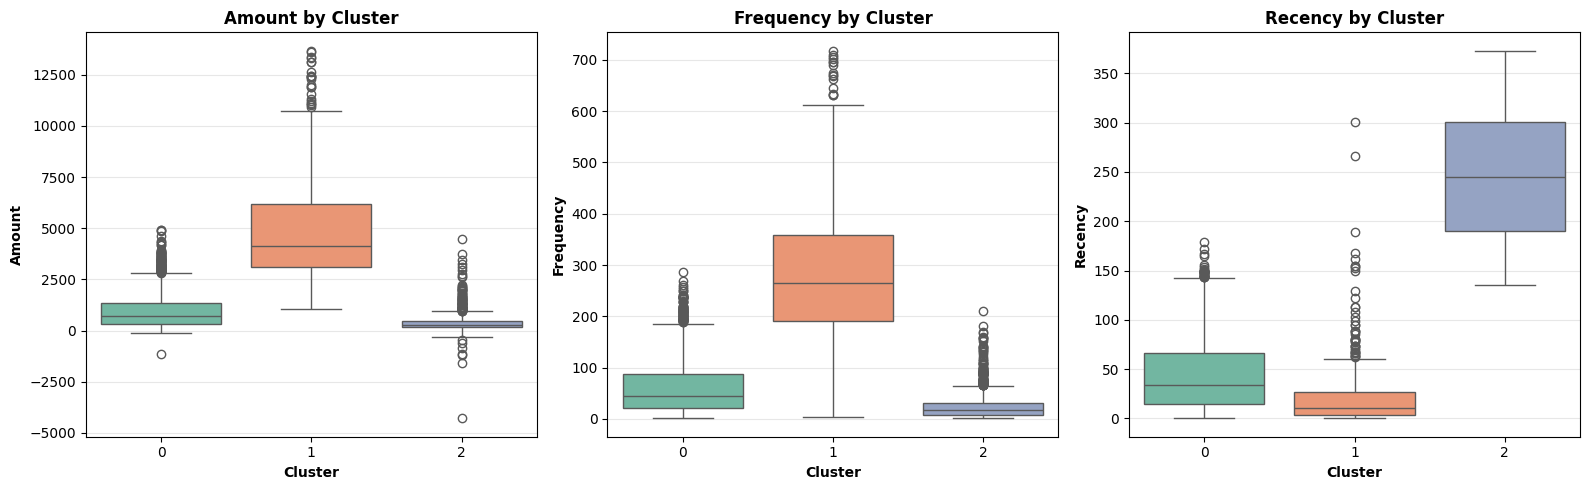

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(["Amount", "Frequency", "Recency"]):
    sns.boxplot(
        x="Cluster",
        y=metric,
        data=rfm,
        hue="Cluster",
        ax=axes[i],
        palette="Set2",
        legend=False,
    )
    axes[i].set_title(f"{metric} by Cluster", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Cluster", fontweight="bold")
    axes[i].set_ylabel(metric, fontweight="bold")
    axes[i].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
cluster_profile = rfm.groupby("Cluster")[["Amount", "Frequency", "Recency"]].agg(
    ["mean", "median", "count"]
)
cluster_profile_df = pd.DataFrame(cluster_profile)

In [50]:
cluster_profile_df

Amount                   Frequency                  Recency  \
                mean    median count        mean median count        mean   
Cluster                                                                     
0         951.730177   691.135  2726   59.516141   45.0  2726   44.497799   
1        4898.735571  4122.280   499  286.891784  265.0   499   21.703407   
2         388.568259   288.920  1068   25.502809   17.0  1068  248.295880   

                      
        median count  
Cluster               
0         34.0  2726  
1         10.0   499  
2        244.5  1068

In [51]:
print(rfm["Cluster"].value_counts().sort_index())
print("\nPercentage distribution:")
print(rfm["Cluster"].value_counts(normalize=True).sort_index() * 100)

Cluster
0    2726
1     499
2    1068
Name: count, dtype: int64

Percentage distribution:
Cluster
0    63.498719
1    11.623573
2    24.877708
Name: proportion, dtype: float64


In [52]:
# contribution by cluster
revenue_by_cluster = rfm.groupby("Cluster")["Amount"].sum()
revenue_pct = (revenue_by_cluster / revenue_by_cluster.sum() * 100).round(1)

print("Revenue Contribution:")
print(revenue_pct)
print(f"\nTotal Revenue: £{rfm['Amount'].sum():,.0f}")

Revenue Contribution:
Cluster
0    47.6
1    44.8
2     7.6
Name: Amount, dtype: float64

Total Revenue: £5,453,876


### Hierarchical Clustering

Hierarchical clustering creates clusters with a top-to-bottom ordering, similar to how files and folders are organized on a hard disk.

There are two types of hierarchical clustering:
- **Divisive (Top-Down)**
- **Agglomerative (Bottom-Up)**

### Single Linkage

In single linkage hierarchical clustering, the distance between two clusters is defined as the **shortest distance between any two points**, one from each cluster.  
For example, the distance between clusters **r** and **s** is the distance between their two closest points.
![alt text](image.png)


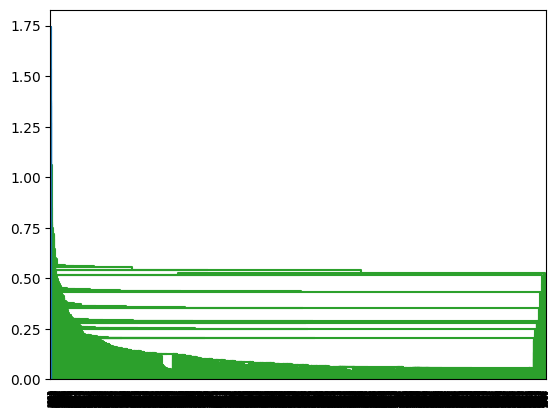

In [53]:
mergings = linkage(rfm_df_scaled, method="single", metric="euclidean")
dendrogram(mergings)
plt.show()

### Complete Linkage

In complete linkage hierarchical clustering, the distance between two clusters is defined as the **longest distance between any two points**, one from each cluster.  
For example, the distance between clusters **r** and **s** is the distance between their two furthest points.

![alt text](image-1.png)

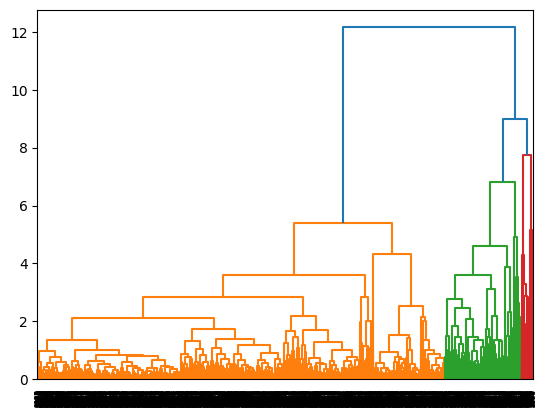

In [54]:
mergings = linkage(rfm_df_scaled, method="complete", metric="euclidean")
dendrogram(mergings)
plt.show()

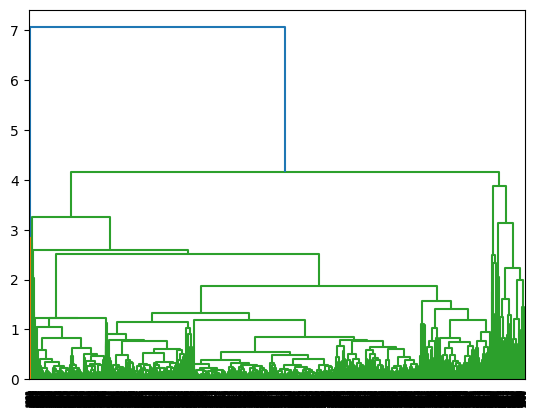

In [55]:
mergings = linkage(rfm_df_scaled, method="average", metric="euclidean")
dendrogram(mergings)
plt.show()

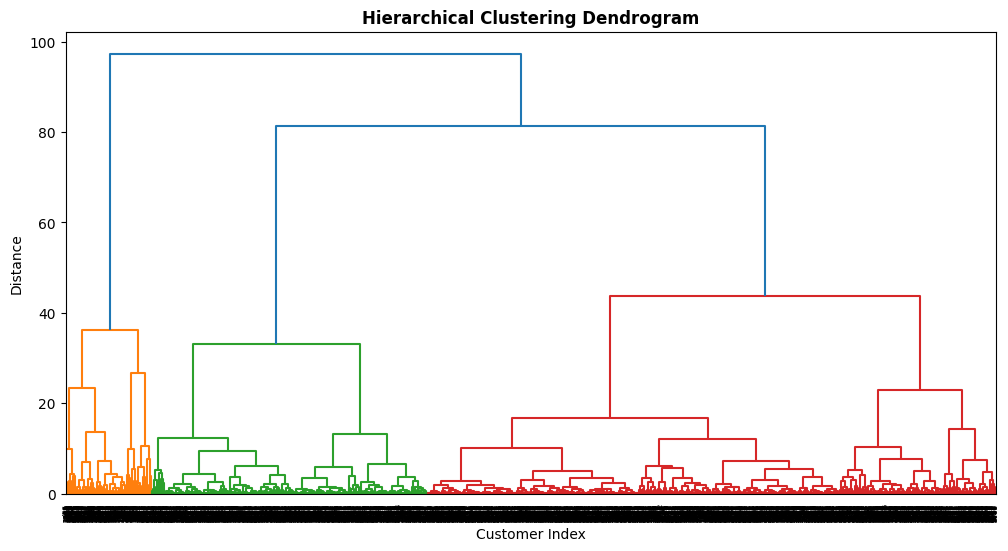

In [56]:
mergings = linkage(rfm_df_scaled, method="ward", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(mergings)
plt.title("Hierarchical Clustering Dendrogram", fontweight="bold")
plt.xlabel("Customer Index")
plt.ylabel("Distance")
plt.show()

In [58]:
rfm

,CustomerID,Amount,Frequency,Recency,Cluster
0,12346.0,0.00,2,325,2
1,12347.0,4310.00,182,1,1
2,12348.0,1797.24,31,74,0
3,12349.0,1757.55,73,18,0
4,12350.0,334.40,17,309,2
...,...,...,...,...,...
4366,18278.0,173.90,9,73,0
4367,18280.0,180.60,10,277,2
4368,18281.0,80.82,7,180,2
4369,18282.0,176.60,13,7,0


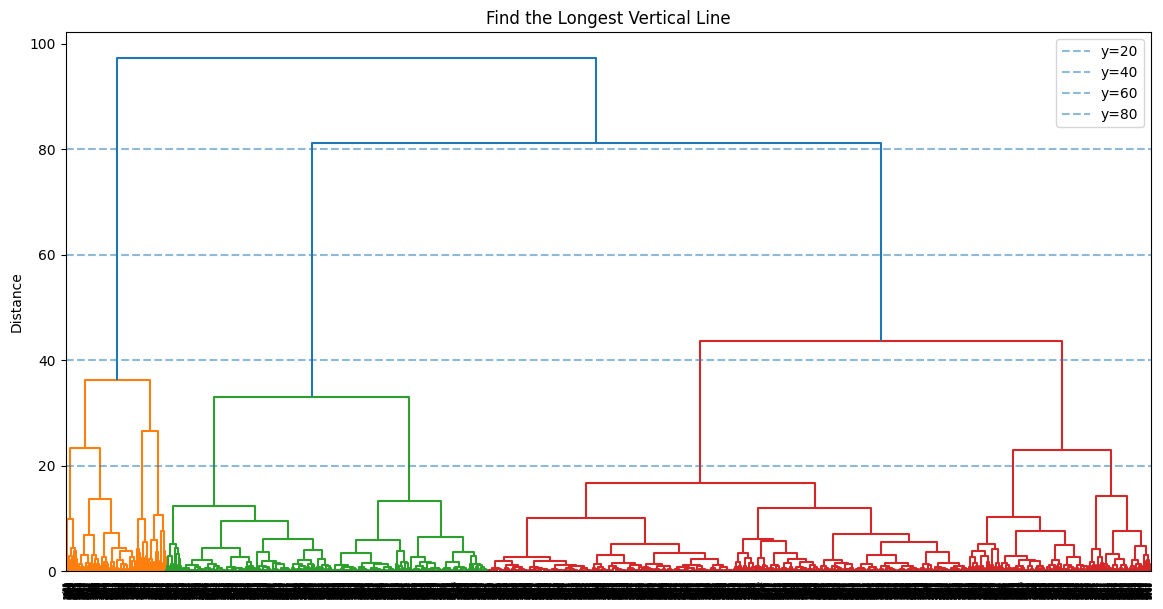

In [ ]:
plt.figure(figsize=(14, 7))
dendrogram(mergings)
plt.title("Find the Longest Vertical Line")
plt.ylabel("Distance")

# Test multiple cuts
for y in [20, 40, 60, 80]:
    plt.axhline(y=y, linestyle="--", alpha=0.5, label=f"y={y}")

plt.legend()
plt.show()

                   Amount   Frequency     Recency
Cluster_Hier                                     
0              431.489499   27.980392  228.125490
1             5520.878367  288.288945   20.464824
2             1032.983860   69.550763   37.521374


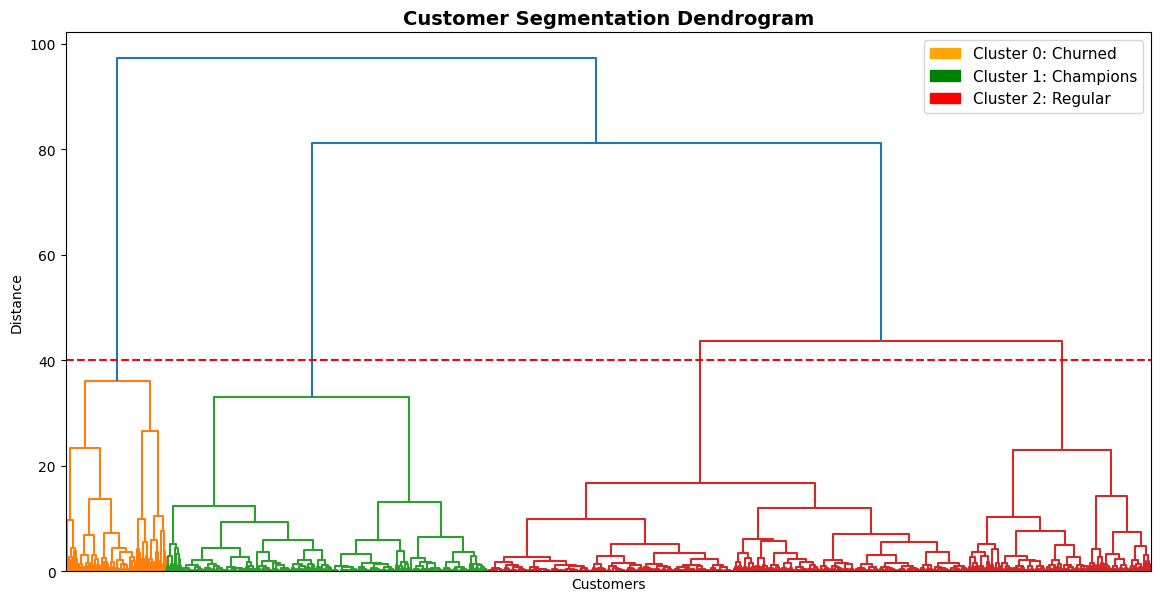

In [ ]:
rfm["Cluster_Hier"] = cut_tree(mergings, n_clusters=3).flatten()

# cluster profiles
profile = rfm.groupby("Cluster_Hier")[["Amount", "Frequency", "Recency"]].mean()
print(profile)

# Label clusters
labels = {0: "Churned", 1: "Champions", 2: "Regular"}

plt.figure(figsize=(14, 7))
dendrogram(mergings, no_labels=True)
plt.axhline(y=40, color="red", linestyle="--", label="Cut at 3 clusters")
plt.title("Customer Segmentation Dendrogram", fontsize=14, fontweight="bold")
plt.xlabel("Customers")
plt.ylabel("Distance")

legend = [
    Patch(color="orange", label=f"Cluster 0: {labels[0]}"),
    Patch(color="green", label=f"Cluster 1: {labels[1]}"),
    Patch(color="red", label=f"Cluster 2: {labels[2]}"),
]
plt.legend(handles=legend, fontsize=11)
plt.show()

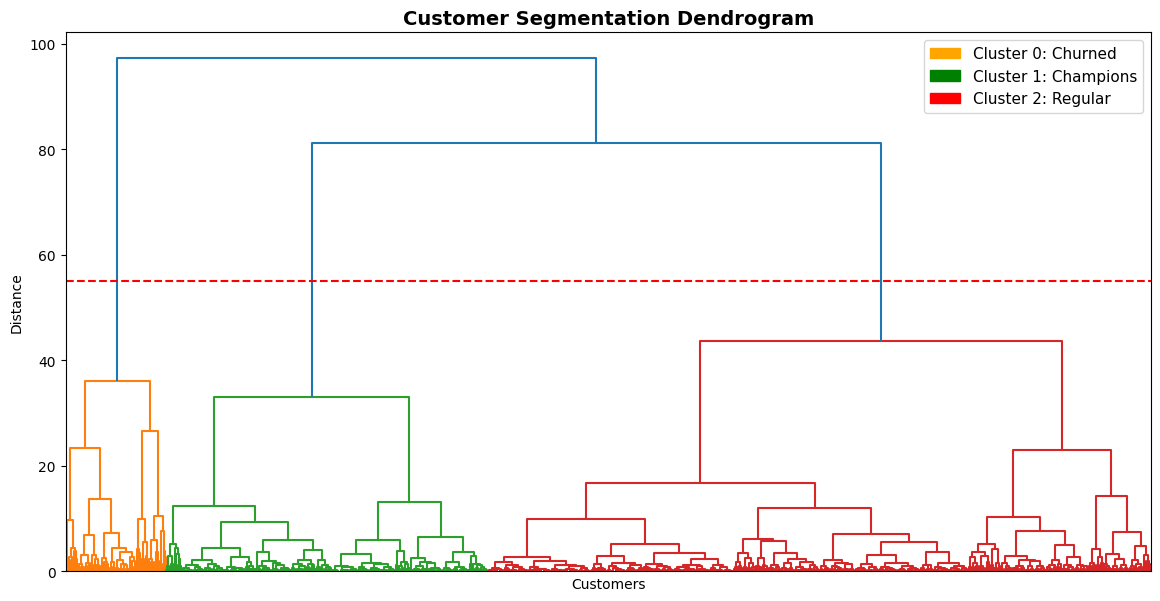

In [ ]:
rfm["Cluster_Hier"] = cut_tree(mergings, n_clusters=3).flatten()
plt.figure(figsize=(14, 7))
dendrogram(mergings, no_labels=True)
plt.axhline(y=55, color="red", linestyle="--", label="Cut at 3 clusters")
plt.title("Customer Segmentation Dendrogram", fontsize=14, fontweight="bold")
plt.xlabel("Customers")
plt.ylabel("Distance")

legend = [
    Patch(color="orange", label=f"Cluster 0: {labels[0]}"),
    Patch(color="green", label=f"Cluster 1: {labels[1]}"),
    Patch(color="red", label=f"Cluster 2: {labels[2]}"),
]
plt.legend(handles=legend, fontsize=11)
plt.show()

In [ ]:
hier_labels = {0: "Churned", 1: "Champions", 2: "Regular"}

rfm["Segment"] = rfm["Cluster_Hier"].map(hier_labels)
print(rfm["Segment"].value_counts())

Segment
Regular      2620
Churned      1275
Champions     398
Name: count, dtype: int64


Dataset is not suitable for DBSCAN 

In [ ]:
tests = [
    (0.5, 5),
    (0.7, 7),
    (0.9, 7),
    (1.1, 10),
    (1.3, 10),
    (0.2, 5),
    (0.3, 5),
    (0.4, 7),
]

for eps, min_s in tests:
    db = DBSCAN(eps=eps, min_samples=min_s)
    rfm["Cluster_DBSCAN"] = db.fit_predict(rfm_df_scaled)

    print(f"eps={eps}, min_samples={min_s}")
    print(rfm["Cluster_DBSCAN"].value_counts())
    print()

eps=0.5, min_samples=5
Cluster_DBSCAN
 0    4176
-1      83
 5       8
 3       7
 1       7
 2       7
 4       5
Name: count, dtype: int64

eps=0.7, min_samples=7
Cluster_DBSCAN
 0    4245
-1      41
 1       7
Name: count, dtype: int64

eps=0.9, min_samples=7
Cluster_DBSCAN
 0    4278
-1      15
Name: count, dtype: int64

eps=1.1, min_samples=10
Cluster_DBSCAN
 0    4282
-1      11
Name: count, dtype: int64

eps=1.3, min_samples=10
Cluster_DBSCAN
 0    4287
-1       6
Name: count, dtype: int64

eps=0.2, min_samples=5
Cluster_DBSCAN
 0     3714
-1      495
 1       18
 6       11
 5        6
 2        6
 3        5
 8        5
 4        5
 10       5
 7        5
 13       5
 11       5
 12       4
 9        4
Name: count, dtype: int64

eps=0.3, min_samples=5
Cluster_DBSCAN
 0    3991
-1     287
 1       6
 3       5
 2       4
Name: count, dtype: int64

eps=0.4, min_samples=7
Cluster_DBSCAN
 0    4075
-1     201
 2      10
 1       7
Name: count, dtype: int64



In [ ]:
rfm.drop("Cluster_DBSCAN", axis=1)

,CustomerID,Amount,Frequency,Recency,Cluster,Cluster_Hier,Segment
0,12346.0,0.00,2,325,2,0,Churned
1,12347.0,4310.00,182,1,1,1,Champions
2,12348.0,1797.24,31,74,0,2,Regular
3,12349.0,1757.55,73,18,0,2,Regular
4,12350.0,334.40,17,309,2,0,Churned
...,...,...,...,...,...,...,...
4366,18278.0,173.90,9,73,0,2,Regular
4367,18280.0,180.60,10,277,2,0,Churned
4368,18281.0,80.82,7,180,2,0,Churned
4369,18282.0,176.60,13,7,0,2,Regular


# Customer Segmentation Project Documentation

## Project Overview

**Project Type:** Unsupervised Machine Learning – Customer Clustering  
**Dataset:** Online Retail Dataset (Kaggle)  
**Dataset Size:** 541,909 transactions, 8 columns  
**Time Period:** December 2010 – December 2011
## Business Goal

The objective of this project is to use the online retail transactional dataset to build an **RFM (Recency, Frequency, Monetary) clustering model**.  
The goal is to segment customers based on their purchasing behavior and identify the most valuable customer groups that the company should prioritize and target.

## Original Features

| Column        | Description                          | Data Type |
|---------------|--------------------------------------|-----------|
| InvoiceNo     | Unique transaction identifier        | String    |
| StockCode     | Product code                         | String    |
| Description   | Product description                  | String    |
| Quantity      | Number of items purchased            | Integer   |
| InvoiceDate   | Transaction date and time            | String    |
| UnitPrice     | Price per unit                       | Float     |
| CustomerID    | Unique customer identifier           | Float     |
| Country       | Customer's country                   | String    |

## Data Quality Issues Identified

- **Missing CustomerIDs:** 135,080 records (24.9% of the dataset)
- **Missing Descriptions:** 1,454 products
- **Negative Quantities:** Indicates product returns or order cancellations
- **Zero or Negative Prices:** Represents invalid pricing entries
- **Outliers:** Extreme values observed in quantity and unit price

## Data Cleaning

- **Removed missing CustomerIDs:** Customer segmentation is not possible without unique customer identifiers
- **Removed missing product descriptions:** Incomplete transaction records were excluded
- **Dropped negative quantities:** Focused only on completed purchases by excluding returns and cancellations
- **Filtered zero or negative prices:** Invalid pricing records were removed from the dataset


## Feature Engineering

### Created Amount Column
A new feature was created to represent the total transaction value:

**Amount = Quantity × UnitPrice**

### DateTime Conversion
- Converted `InvoiceDate` from string format to datetime
- Original format: `DD-MM-YYYY HH:MM`
- Converted to a proper datetime object to enable time-based analysis (e.g., recency calculation)


## RFM Calculation

**Reference Date:** December 9, 2011 (latest transaction + 1 day)

- **Recency (R):** Days since last purchase *(lower is better)* 

    Formula: `(Reference Date − Last Purchase Date).days`
- **Frequency (F):** Number of transactions *(higher is better)* 

    Formula: Count of unique `InvoiceNo` per customer
- **Monetary (M):** Total customer spending *(higher is better)* 

    Formula: Sum of `Amount` per customer

### Outlier Handling
- Removed extreme values using the **IQR method** on all RFM features  
- **Final dataset:** 4,293 customers

## Step 6: Feature Scaling

- Applied **StandardScaler (Z-score normalization)** to RFM features  
- Ensures all features contribute equally to clustering  

## Clustering Algorithms Applied

### K-Means Clustering
- **n_clusters:** 3 (selected using Elbow Method and Silhouette Score)
- **Initialization:** k-means++
- **Max Iterations:** 50
- **Algorithm:** Lloyd

**Model Selection:**  
- Elbow Method tested k = 2–10 (elbow at 3–4)  
- Silhouette Score used to validate cluster quality

### Hierarchical Clustering
- **Method:** Agglomerative
- **Linkage:** Ward
- **Distance Metric:** Euclidean

**Process:**  
- Built linkage matrix and dendrogram  
- Cut tree to form **3 clusters**

## DBSCAN (Density-Based Clustering)

### Hyperparameter Tuning Results

| eps | min_samples | Result                          | Issue                          |
|-----|-------------|----------------------------------|--------------------------------|
| 0.2 | 5           | 1 cluster (3714) + 495 noise     | 11.5% noise                    |
| 0.3 | 5           | 1 cluster (3991) + 287 noise     | Poor separation                |
| 0.4 | 7           | 1 cluster (4075) + 201 noise     | Single dominant cluster        |
| 0.5 | 5           | 1 cluster (4176) + 83 noise      | Multiple tiny clusters         |
| 0.7–1.3 | 7–10    | 1 large cluster (4200+)          | Everyone merged                |

### Conclusion
- DBSCAN failed to produce meaningful clusters  
- Too much noise or one dominant cluster  
- **K-Means outperformed DBSCAN**

### Why DBSCAN Failed
- RFM clusters are overlapping and spherical  
- DBSCAN favors irregular shapes and density gaps  
- No clear density separation in this data

## Key Findings

### Cluster 0: Regular Customers (63.5% | 2,726 customers)
- Avg. Spending: £952  
- Avg. Frequency: 60 orders  
- Avg. Recency: 44 days  

### Cluster 1: Champions (11.6% | 499 customers)
- Avg. Spending: £4,899  
- Avg. Frequency: 287 orders  
- Avg. Recency: 22 days  

### Cluster 2: Churned / At-Risk (24.9% | 1,068 customers)
- Avg. Spending: £389  
- Avg. Frequency: 26 orders  
- Avg. Recency: 248 days  

## Issues Faced & Solutions

### Missing CustomerID
- **Issue:** Customers cannot be segmented without IDs  
- **Solution:** Removed records with missing `CustomerID`

### Negative Quantities (Returns)
- **Issue:** Returns distort spending behavior  
- **Solution:** Kept only positive quantities  
- **Note:** Returns could be analyzed separately

### Extreme Outliers
- **Issue:** Very large orders and prices skewed results  
- **Solution:** Applied IQR-based outlier removal on RFM features  
- **Impact:** Customers reduced from 4,372 to 4,293 (1.8%)

### Feature Scale Differences
- **Issue:** RFM features were on different scales  
- **Solution:** Applied **StandardScaler**  
- **Reason:** K-Means is sensitive to feature scale

### Choosing the Number of Clusters
- **Issue:** Selecting optimal `k`  
- **Solution:** Used Elbow Method, Silhouette Score 
- **Result:** **k = 3** produced clear and actionable segments

### DBSCAN Failure
- **Issue:** DBSCAN produced one large cluster or too much noise  
- **Solution:** Dropped DBSCAN and finalized **K-Means**  
- **Lesson:** Algorithm choice must match data structure

### Dendrogram Confusion
- **Issue:** Dendrogram colors did not match final clusters  
- **Explanation:** Colors are visual aids; `cut_tree(n_clusters=3)` defines clusters  
- **Solution:** Trusted the clustering output, not dendrogram colors

## Recommendations

Based on the insights from customer segmentation, the following actions are recommended:

- **Set up three separate email campaigns**, one for each customer segment

### Champions
- Launch a **VIP program** with exclusive offers and early access

### Regular Customers
- Introduce a **loyalty points program** to increase purchase frequency

### Churned / At-Risk Customers
- Run **win-back campaigns** with targeted discount offers
- Build a **churn prediction model** to identify Regular customers at risk of churning

## Conclusion

This project successfully identified **three distinct customer segments** using **K-Means and Hierarchical clustering**:

- **499 Champions** (11.6%)
- **2,726 Regular Customers** (63.5%)
- **1,068 Churned / At-Risk Customers** (24.9%)